# Monte Carlo Simulation Steps - Stock Market Simulator

This notebook demonstrates the complete step-by-step process of running a Monte Carlo simulation for stock market forecasting, as implemented in the Stock Market Simulator application.

## Overview

The Monte Carlo simulation process involves:
1. **Data Collection**: Fetching historical market data
2. **Data Processing**: Selecting relevant time periods and calculating returns
3. **Statistical Analysis**: Computing mean (μ) and standard deviation (σ) of returns
4. **Simulation**: Running multiple random walk scenarios
5. **Results Analysis**: Computing percentiles and visualizing outcomes

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Data Collection

Fetch historical stock data for the specified ticker and time period.

In [2]:
def fetch_market_data(ticker, start_date, end_date):
    """
    Fetch historical market data for a given ticker.
    
    Args:
        ticker: Stock symbol (e.g., 'SPY')
        start_date: Start date for data collection
        end_date: End date for data collection
    
    Returns:
        DataFrame with OHLCV data
    """
    print(f"Fetching data for {ticker} from {start_date} to {end_date}")
    
    # Download data using yfinance
    # stock_data = yf.download(ticker, start=start_date, end=end_date)
    # TODO: use this instead of download because stock_data does not contain "Dividends" column
    # stock_data = yf.Ticker("SPY").history(start="2020-01-01", end="2025-01-01")

    stock_data = yf.Ticker(ticker).history(start=start_date, end=end_date)
    
    print(stock_data.head())

    if stock_data.empty:
        raise ValueError(f"No data found for ticker {ticker}")
    
    # Reset index to make date a column
    stock_data = stock_data.reset_index()
    stock_data['date'] = stock_data['Date']
    stock_data = stock_data.drop('Date', axis=1)
    print(stock_data.head())
    
    # Calculate dividend yield (simplified - using actual dividends if available)
    if 'Dividends' in stock_data.columns:
        stock_data['DividendYield'] = stock_data['Dividends'] / stock_data['Close']
    else:
        stock_data['DividendYield'] = 0.0  # Default to 0 if no dividend data
    
    print(f"✓ Fetched {len(stock_data)} data points for {ticker}")
    return stock_data

# Example usage
ticker = "SPY"
end_date = datetime.now()
lookback_years = 10
start_date = end_date - timedelta(days=lookback_years * 365.25)

market_data = fetch_market_data(ticker, start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d'))
market_data.head()

Fetching data for SPY from 2016-04-14 to 2026-04-15
                                 Open        High         Low       Close  \
Date                                                                        
2016-04-14 00:00:00-04:00  176.774070  177.224351  176.374762  176.723083   
2016-04-15 00:00:00-04:00  176.723097  176.859034  176.204847  176.527695   
2016-04-18 00:00:00-04:00  176.527706  177.802090  175.865027  177.768112   
2016-04-19 00:00:00-04:00  178.192887  178.583691  177.513213  178.328812   
2016-04-20 00:00:00-04:00  178.371287  179.195390  177.895519  178.498734   

                             Volume  Dividends  Stock Splits  Capital Gains  
Date                                                                         
2016-04-14 00:00:00-04:00  65212900        0.0           0.0            0.0  
2016-04-15 00:00:00-04:00  75761600        0.0           0.0            0.0  
2016-04-18 00:00:00-04:00  82531000        0.0           0.0            0.0  
2016-04-19 00:00:0

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,date,DividendYield
0,176.774070,177.224351,176.374762,176.723083,65212900,0.0,0.0,0.0,2016-04-14 00:00:00-04:00,0.0
1,176.723097,176.859034,176.204847,176.527695,75761600,0.0,0.0,0.0,2016-04-15 00:00:00-04:00,0.0
2,176.527706,177.802090,175.865027,177.768112,82531000,0.0,0.0,0.0,2016-04-18 00:00:00-04:00,0.0
3,178.192887,178.583691,177.513213,178.328812,88316100,0.0,0.0,0.0,2016-04-19 00:00:00-04:00,0.0
4,178.371287,179.195390,177.895519,178.498734,81100300,0.0,0.0,0.0,2016-04-20 00:00:00-04:00,0.0


In [3]:
market_data["DividendYield"].sort_values(ascending=False)

172    0.006840
990    0.006685
678    0.006647
45     0.006112
108    0.005908
         ...   
13     0.000000
14     0.000000
15     0.000000
16     0.000000
1      0.000000
Name: DividendYield, Length: 2514, dtype: float64

In [4]:
market_data.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,date,DividendYield
2509,676.390015,677.080017,671.460022,676.010010,93606100,0.0,0.0,0.0,2026-04-08 00:00:00-04:00,0.0
2510,674.840027,681.159973,673.770020,679.909973,57134400,0.0,0.0,0.0,2026-04-09 00:00:00-04:00,0.0
2511,681.320007,682.030029,678.450012,679.460022,42253500,0.0,0.0,0.0,2026-04-10 00:00:00-04:00,0.0
2512,677.409973,686.299988,676.580017,686.099976,54185800,0.0,0.0,0.0,2026-04-13 00:00:00-04:00,0.0
2513,687.690002,694.580017,687.659973,694.460022,59884831,0.0,0.0,0.0,2026-04-14 00:00:00-04:00,0.0


In [5]:
# reinvest all dividends. this is not how to do it, because the daily returns should be calculated on the adjusted close, not the close.
# we should not calculate daily returns. we should simulate the capital invested in the stock, and then calculate the returns based on that.

def simulate_investment():
    """
    Simulate investment growth based on daily returns.
    
    Args:
        initial_investment: Starting capital
        daily_returns: Array of daily return percentages (e.g., 0.01 for 1%)
    
    Returns:
        Array of daily values showing investment growth
    """
    values = [initial_investment]
    for daily_return in daily_returns:
        # Convert percentage to decimal and apply to current value
        current_value = values[-1]
        new_value = current_value * (1 + daily_return)
        values.append(new_value)
    
    return np.array(values)




reinvest_dividends = True
market_data_1 = market_data.copy()
if reinvest_dividends:
    market_data_1['Close'] = market_data_1['Close'] * (1 + market_data_1['DividendYield'])



## Step 3: Data Processing and Return Calculation

Calculate daily returns from price changes. This gives us the actual market returns excluding contributions.

Daily Return Statistics:
  Mean (μ): 0.000679 (0.0679% daily)
  Std Dev (σ): 0.011307 (1.1307% daily)
  Annualized Mean: 0.171161 (17.1161% yearly)
  Annualized Std Dev: 0.179498 (17.9498% yearly)


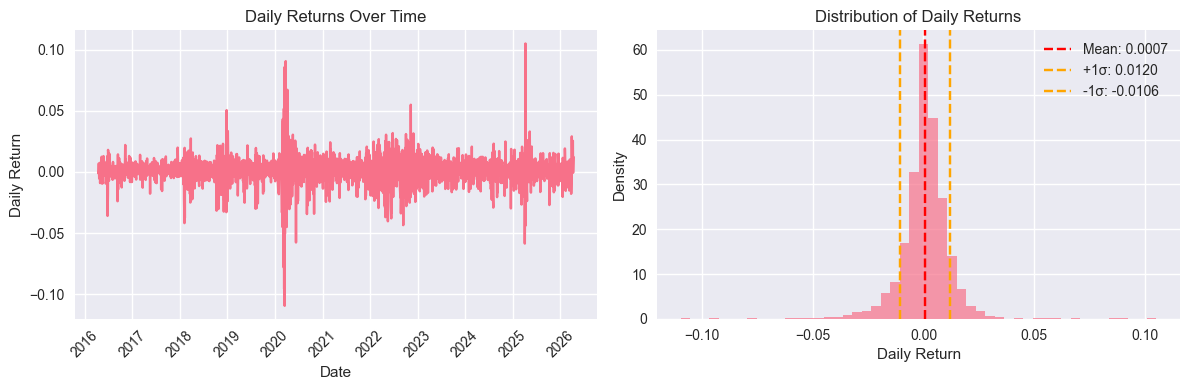

In [6]:
def calculate_returns(data):
    """
    Calculate daily returns from price changes.
    
    Args:
        data: DataFrame with OHLCV data
    
    Returns:
        DataFrame with additional returns column
    """
    # Calculate daily price returns
    data['price_return'] = data['Close'].pct_change().fillna(0) + data['DividendYield'].fillna(0)
    
    # Calculate statistics
    mu = data['price_return'].mean()
    sigma = data['price_return'].std()
    
    print(f"Daily Return Statistics:")
    print(f"  Mean (μ): {mu:.6f} ({mu*100:.4f}% daily)")
    print(f"  Std Dev (σ): {sigma:.6f} ({sigma*100:.4f}% daily)")
    print(f"  Annualized Mean: {(mu*252):.6f} ({(mu*252)*100:.4f}% yearly)")
    print(f"  Annualized Std Dev: {(sigma*np.sqrt(252)):.6f} ({(sigma*np.sqrt(252))*100:.4f}% yearly)")
    
    return data, mu, sigma

# Process the data
processed_data, mu, sigma = calculate_returns(market_data_1.copy())

# Plot returns distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(processed_data['date'], processed_data['price_return'])
plt.title('Daily Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.hist(processed_data['price_return'], bins=50, alpha=0.7, density=True)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Density')
plt.axvline(mu, color='red', linestyle='--', label=f'Mean: {mu:.4f}')
plt.axvline(mu + sigma, color='orange', linestyle='--', label=f'+1σ: {mu + sigma:.4f}')
plt.axvline(mu - sigma, color='orange', linestyle='--', label=f'-1σ: {mu - sigma:.4f}')
plt.legend()

plt.tight_layout()
plt.show()

## Step 4: Monte Carlo Simulation Setup

Set up parameters for the Monte Carlo simulation.

In [7]:
# Simulation parameters
horizon_years = 10
simulations = 1000
baseline = 1.0  # Start all simulations from same baseline

# Calculate simulation steps (monthly)
steps = horizon_years * 12

print(f"Monte Carlo Simulation Parameters:")
print(f"  Horizon: {horizon_years} years")
print(f"  Simulations: {simulations:,}")
print(f"  Time steps: {steps} (monthly)")
print(f"  Baseline value: {baseline}")
print(f"  Mean return (μ): {mu:.6f}")
print(f"  Std deviation (σ): {sigma:.6f}")

Monte Carlo Simulation Parameters:
  Horizon: 10 years
  Simulations: 1,000
  Time steps: 120 (monthly)
  Baseline value: 1.0
  Mean return (μ): 0.000679
  Std deviation (σ): 0.011307


## Step 5: Run Monte Carlo Simulation

Generate multiple random walk scenarios using the calculated statistics.

In [8]:
def run_monte_carlo_simulation(mu, sigma, steps, simulations, baseline=1.0):
    """
    Run Monte Carlo simulation using geometric Brownian motion.
    
    Args:
        mu: Mean of daily returns
        sigma: Standard deviation of daily returns
        steps: Number of time steps
        simulations: Number of simulations to run
        baseline: Starting value
    
    Returns:
        Array of simulation paths
    """
    print(f"Running {simulations:,} simulations with {steps} steps each...")
    
    # Initialize array to store all simulation paths
    paths = np.zeros((steps, simulations))
    
    # Run simulations
    for i in range(simulations):
        prices = [baseline]
        
        for step in range(steps):
            # Generate random shock from normal distribution
            shock = np.random.normal(mu, sigma)
            # Apply geometric Brownian motion
            prices.append(prices[-1] * (1 + shock))
        
        # Store the path (excluding the initial baseline)
        paths[:, i] = prices[1:]
        
        # Progress indicator
        if (i + 1) % 100 == 0:
            print(f"  Completed {i + 1}/{simulations} simulations")
    
    print(f"✓ Monte Carlo simulation completed!")
    return paths

# Run the simulation
np.random.seed(42)  # For reproducibility
simulation_paths = run_monte_carlo_simulation(mu, sigma, steps, simulations, baseline)

print(f"Simulation paths shape: {simulation_paths.shape}")
print(f"Sample final values: {simulation_paths[-1, :10]}")

Running 1,000 simulations with 120 steps each...
  Completed 100/1000 simulations
  Completed 200/1000 simulations
  Completed 300/1000 simulations
  Completed 400/1000 simulations
  Completed 500/1000 simulations
  Completed 600/1000 simulations
  Completed 700/1000 simulations
  Completed 800/1000 simulations
  Completed 900/1000 simulations
  Completed 1000/1000 simulations
✓ Monte Carlo simulation completed!
Simulation paths shape: (120, 1000)
Sample final values: [0.9680815  1.19068211 1.09244049 1.16913012 0.8983837  1.085945
 1.13905816 1.42241375 1.20212759 1.26075472]


## Step 6: Generate Future Dates

Create date series for the forecast period.

In [9]:
def generate_forecast_dates(start_date, horizon_years):
    """
    Generate monthly dates for the forecast period.
    
    Args:
        start_date: Starting date for forecast
        horizon_years: Number of years to forecast
    
    Returns:
        DatetimeIndex with forecast dates
    """
    dates = pd.date_range(
        start=start_date + pd.offsets.MonthBegin(1),  # Start from next month
        periods=horizon_years * 12,
        freq='MS'  # Month start
    )
    return dates

# Generate forecast dates
last_historical_date = market_data['date'].iloc[-1]
forecast_dates = generate_forecast_dates(last_historical_date, horizon_years)

print(f"Historical data ends: {last_historical_date.strftime('%Y-%m-%d')}")
print(f"Forecast starts: {forecast_dates[0].strftime('%Y-%m-%d')}")
print(f"Forecast ends: {forecast_dates[-1].strftime('%Y-%m-%d')}")
print(f"Number of forecast dates: {len(forecast_dates)}")

Historical data ends: 2026-04-14
Forecast starts: 2026-05-01
Forecast ends: 2036-04-01
Number of forecast dates: 120


## Step 7: Calculate Percentiles

Compute median, 10th, and 90th percentiles for each time step.

In [10]:
def calculate_percentiles(paths):
    """
    Calculate percentiles for simulation paths.
    
    Args:
        paths: Array of simulation paths
    
    Returns:
        Tuple of (median, p10, p90) arrays
    """
    print("Calculating percentiles...")
    
    median = np.median(paths, axis=1)
    p10 = np.percentile(paths, 10, axis=1)
    p90 = np.percentile(paths, 90, axis=1)
    
    print(f"✓ Percentiles calculated")
    print(f"  Final median value: {median[-1]:.3f}")
    print(f"  Final 10th percentile: {p10[-1]:.3f}")
    print(f"  Final 90th percentile: {p90[-1]:.3f}")
    
    return median, p10, p90

# Calculate percentiles
median_values, p10_values, p90_values = calculate_percentiles(simulation_paths)

Calculating percentiles...
✓ Percentiles calculated
  Final median value: 1.079
  Final 10th percentile: 0.923
  Final 90th percentile: 1.261


## Step 8: Visualization

Create comprehensive visualizations of the Monte Carlo simulation results.

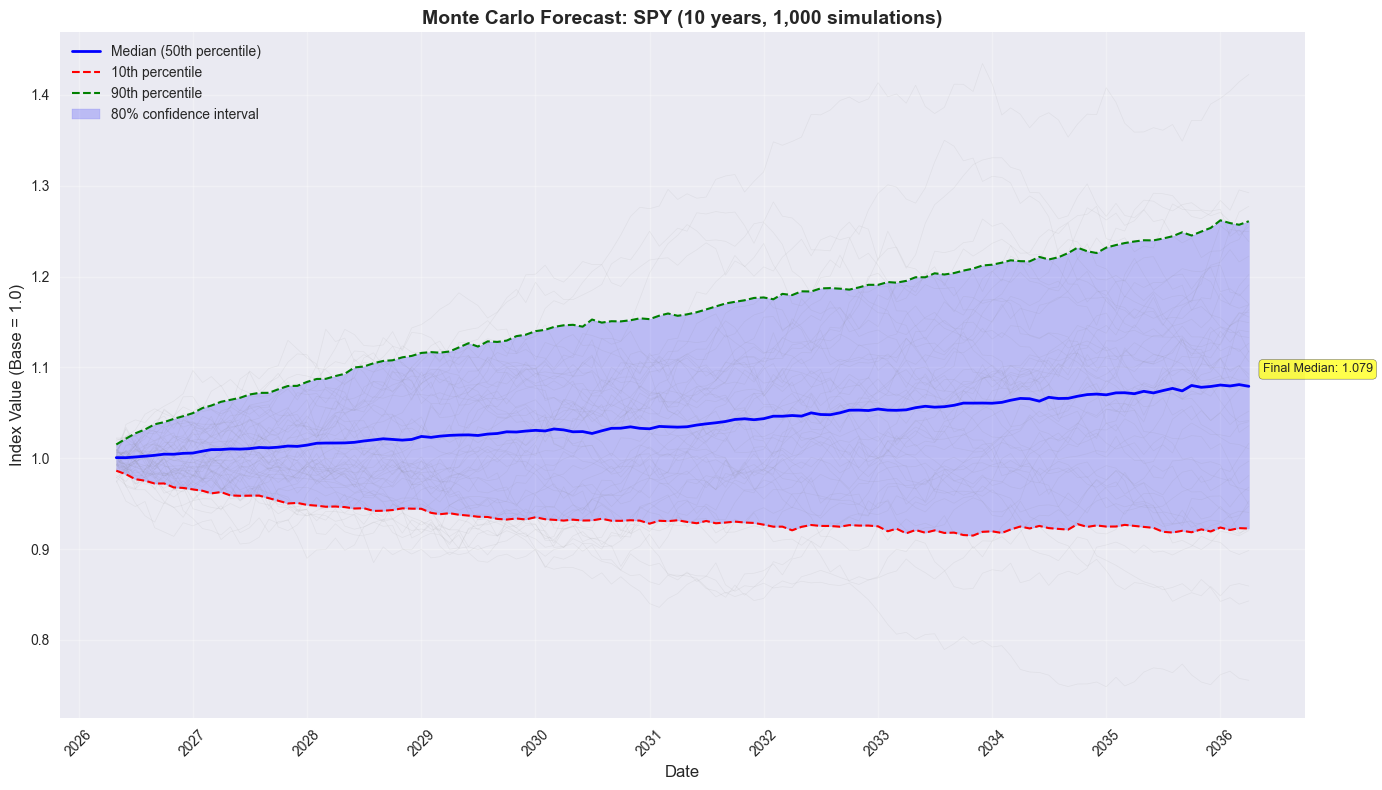

In [11]:
def plot_monte_carlo_results(dates, median, p10, p90, sample_paths=None, ticker="SPY"):
    """
    Plot Monte Carlo simulation results.
    
    Args:
        dates: Forecast dates
        median: Median values
        p10: 10th percentile values
        p90: 90th percentile values
        sample_paths: Sample simulation paths to show (optional)
        ticker: Stock ticker symbol
    """
    plt.figure(figsize=(14, 8))
    
    # Plot sample paths (if provided)
    if sample_paths is not None:
        for i in range(min(50, sample_paths.shape[1])):  # Show up to 50 sample paths
            plt.plot(dates, sample_paths[:, i], 'gray', alpha=0.1, linewidth=0.5)
    
    # Plot percentiles
    plt.plot(dates, median, 'b-', linewidth=2, label='Median (50th percentile)')
    plt.plot(dates, p10, 'r--', linewidth=1.5, label='10th percentile')
    plt.plot(dates, p90, 'g--', linewidth=1.5, label='90th percentile')
    
    # Fill area between percentiles
    plt.fill_between(dates, p10, p90, alpha=0.2, color='blue', label='80% confidence interval')
    
    # Formatting
    plt.title(f'Monte Carlo Forecast: {ticker} ({horizon_years} years, {simulations:,} simulations)', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Index Value (Base = 1.0)', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    # Add annotations
    plt.annotate(f'Final Median: {median[-1]:.3f}', 
                 xy=(dates[-1], median[-1]), 
                 xytext=(10, 10), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                 fontsize=9)
    
    plt.tight_layout()
    plt.show()

# Plot the results
plot_monte_carlo_results(forecast_dates, median_values, p10_values, p90_values, 
                        simulation_paths[:, :100], ticker)  # Show 100 sample paths

## Conclusion

This notebook demonstrates the complete Monte Carlo simulation process used in the Stock Market Simulator application. The key steps include:

1. **Data Collection**: Fetching historical market data using yfinance
2. **Statistical Analysis**: Computing mean and standard deviation of daily returns
3. **Simulation**: Running thousands of random walk scenarios using geometric Brownian motion
4. **Analysis**: Calculating percentiles and key metrics
5. **Visualization**: Creating comprehensive charts

This mirrors the implementation in the backend service and provides a testing environment for the Monte Carlo simulation functionality.